# **Diplomado IA: Inteligencia Artificial II - Parte 2**. <br> Práctico 32: Aprendizaje Incremental y  Olvido Catastrófico
---
---

## **Profesores:**
- Alain Raymond

### **Ayudante**:

---

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:**

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.


---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Introducción

Este laboratorio se basó en una serie de Notebooks del grupo [Continual AI](https://www.continualai.org/), la cual es una comunidad abierta que busca desarrollar investigación y divulgación sobre Aprendizaje Continuo.

Tal como vimos en clases, el aprendizaje incremental estudia modelos y métodos que permitan un proceso de aprendizaje continuo de varias tareas diferentes.

En este laboratorio vamos a ver cómo se comportan diferentes métodos simples en una secuencia de tareas muy utilizadas para comparación entre métodos.


Lo primero que tenemos que hacer es verificar cómo están los niveles de memoria y disco. Luego verificamos si tenemos acceso a GPU.

In [ ]:
!free -m
!df -h
!nvidia-smi

               total        used        free      shared  buff/cache   available
Mem:           12975         679        8565           2        3731       11976
Swap:              0           0           0
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   44G   70G  39% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.2G  748M  63% /usr/sbin/docker-init
/dev/sda1        74G   49G   26G  66% /opt/bin/.nvidia
tmpfs           6.4G   32K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
Thu Mar 26 16:05:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

In [ ]:
import torch
torch.cuda.is_available()

True

Cargamos todas las librerias que vamos a utilizar durante este laboratorio:

In [ ]:
import random
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Modelo

In [ ]:
# switch to False to use CPU
use_cuda = True

use_cuda = use_cuda and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
torch.manual_seed(1);

El modelo consiste en 2 capas convolucionales más dos capas lineales, se agregan capas de max pooling y funciones de activación.

El modelo utilizado es simple ya que la motivación no es lograr los mejores resultados en cada tarea, sino que nos permite reflejar lo que ocurre cuando no tenemos precauciones al entrenar una nueva tarea.


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

# Dataset

En este laboratorio vamos a utilizar el dataset *MNIST* (LeCun, Yann, et al. "Gradient-based learning applied to document recognition." Proceedings of the IEEE 86.11 (1998): 2278-2324.). Este dataset consiste en 60.000 imágenes de 28x28 pixeles, y cada una es una imagen de un dígito del 0 al 9 escrita a mano. Es decir, tiene 10 clases diferentes (una por dígito).

Por simplicidad vamos a utilizar las funciones de descarga de Continual AI, ya que nos va a facilitar la creación de nuevas tareas.


In [ ]:
!git clone https://github.com/ContinualAI/colab.git continualai/colab

Cloning into 'continualai/colab'...
remote: Enumerating objects: 402, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 402 (delta 88), reused 81 (delta 66), pack-reused 258 (from 1)
Receiving objects: 100% (402/402), 31.20 MiB | 29.59 MiB/s, done.
Resolving deltas: 100% (208/208), done.


Descargamos el dataset en nuestro entorno de colab

In [ ]:
from os import path
import gzip
import pickle
import numpy as np

filename = [
    ["training_images", "train-images-idx3-ubyte.gz"],
    ["test_images", "t10k-images-idx3-ubyte.gz"],
    ["training_labels", "train-labels-idx1-ubyte.gz"],
    ["test_labels", "t10k-labels-idx1-ubyte.gz"]
]

!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz -q --show-progress

!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz -q --show-progress

def save_mnist():
    mnist = {}
    for name in filename[:2]:
        with gzip.open(name[1], 'rb') as f:
            tmp = np.frombuffer(f.read(), np.uint8, offset=16)
            mnist[name[0]] = tmp.reshape(-1, 1, 28, 28).astype(np.float32) / 255
    for name in filename[-2:]:
        with gzip.open(name[1], 'rb') as f:
            mnist[name[0]] = np.frombuffer(f.read(), np.uint8, offset=8)
    with open("mnist.pkl", 'wb') as f:
        pickle.dump(mnist, f)
    print("Save complete.")

save_mnist()

train-images-idx3-u 100%[===================>]   9.45M  12.1MB/s    in 0.8s    
train-labels-idx1-u 100%[===================>]  28.20K  --.-KB/s    in 0.09s   
t10k-images-idx3-ub 100%[===================>]   1.57M  3.05MB/s    in 0.5s    
t10k-labels-idx1-ub 100%[===================>]   4.44K  --.-KB/s    in 0s      
Save complete.


In [ ]:
from continualai.colab.scripts import mnist
mnist.init()

Files already downloaded!


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 349kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


Luego lo cargamos a memoria.

El dataset que estamos utilizando es muy simple, ideal para hacer pruebas de concepto, ya que tiene varias imagenes pequeñas. Al ser pequeñas, estas se pueden cargar en memoria completamente, lo que acelera bastante el proceso de entrenamiento.

Lo bueno de probar estos métodos en pequeños dataset es que nos permite validar nuestra propuesta antes de consumir horas o días de computo probando en otra secuencia de tareas. Pero una vez que validamos las ideas, podemos probar los mismos métodos en otras tareas.

In [ ]:
x_train, y_train, x_test, y_test = mnist.load()

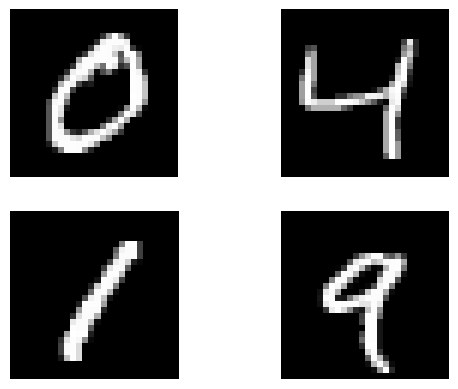

In [ ]:
f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(x_train[1, 0], cmap="gray")
axarr[0,1].imshow(x_train[2, 0], cmap="gray")
axarr[1,0].imshow(x_train[3, 0], cmap="gray")
axarr[1,1].imshow(x_train[4, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

## Permuted MNIST

Esta secuencia de tareas consiste en tomar cada imagen del set original del dataset MNIST, y realizar una permutación de los pixeles para que refleje otros patrones en la imagen.

Cada tarea que queremos agregar es una nueva permutación que se hace a cada una de las imágenes. Por ejemplo, una nueva tarea puede ser mover todos los píxeles uno a la derecha. Pero lo que se hace normalmente es que cada tarea es una permutación aleatoria de todos los píxeles, buscando generar patrones únicos en cada tarea.

In [ ]:
def permute_mnist(mnist, seed):
    """ Given the training set, permute pixels of each img the same way. """

    np.random.seed(seed)
    print("starting permutation...")
    h = w = 28
    perm_inds = list(range(h*w))
    np.random.shuffle(perm_inds)
    # print(perm_inds)
    perm_mnist = []
    for set in mnist:
        num_img = set.shape[0]
        flat_set = set.reshape(num_img, w * h)
        perm_mnist.append(flat_set[:, perm_inds].reshape(num_img, 1, w, h))
    print("done.")
    return perm_mnist

starting permutation...
done.


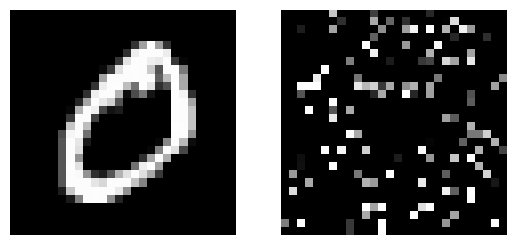

In [ ]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 0)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

starting permutation...
done.


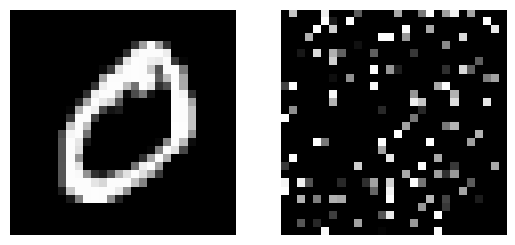

In [ ]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 5)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

# Entrenamiento

Tal como en laboratorios anteriores, tenemos dos funciones que nos ayudan a entrenar e ir verificando cómo van los entrenamientos de nuestro modelo.

**train**: Es la encargada de entrenar el modelo con los datos que le entregamos. Estos deben ser de la tarea actual.

**test**: Nos devuelve el accuracy logrado por el modelo con los datos que le entregamos.

In [ ]:
def train(model, device, x_train, y_train, optimizer, epoch):
    model.train()

    for start in range(0, len(y_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(y_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)
        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

def test(model, device, x_test, y_test):
    model.eval()
    test_loss = 0
    correct = 0
    for start in range(0, len(y_test)-1, 256):
       end = start + 256
       with torch.no_grad():
          x, y = torch.from_numpy(x_test[start:end]), torch.from_numpy(y_test[start:end]).long()
          x, y = x.to(device), y.to(device)
          output = model(x)
          test_loss += F.cross_entropy(output, y).item() # sum up batch loss
          pred = output.max(1, keepdim=True)[1] # get the index of the max logit
          correct += pred.eq(y.view_as(pred)).sum().item()

    test_loss /= len(y_test)
    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(y_test),
        100. * correct / len(y_test)))
    return 100. * correct / len(y_test)

Es importante inicializar el modelo cada vez que queramos entrenar una nueva secuencia, ya que si no lo hacemos estamos partiendo con un modelo que ya tiene información de alguna tarea en sus pesos.

In [ ]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
for epoch in range(1, 5):
   train(model, device, x_train, y_train, optimizer, epoch)
   test(model, device, x_test, y_test)

Train Epoch: 1 	Loss: 0.753721
Test set: Average loss: 0.0013, Accuracy: 9018/10000 (90%)

Train Epoch: 2 	Loss: 0.503353
Test set: Average loss: 0.0007, Accuracy: 9426/10000 (94%)

Train Epoch: 3 	Loss: 0.449079
Test set: Average loss: 0.0005, Accuracy: 9568/10000 (96%)

Train Epoch: 4 	Loss: 0.438308
Test set: Average loss: 0.0005, Accuracy: 9630/10000 (96%)



Con los resultados anteriores, podemos ver que el modelo logró un muy buen rendimiento en la tarea con los datos original. Lo mejor, es que no necesita una gran cantidad de épocas para alcanzar esos resultados.

## Olvido Catastrófico

El mayor problema que tiene el aprender tareas de manera secuencial es lo que se conoce como Olvido Catastrófico, donde al entrenar una nueva tarea, el rendimiento alcanzado en tareas anteriores se ve fuertemente afectado.

Primero veamos el accuracy que alcanza un modelo en dos tareas, cuando fue entrenado solo en la primera:

In [ ]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0005, Accuracy: 9630/10000 (96%)

Testing on the second task:
Test set: Average loss: 0.0099, Accuracy: 1051/10000 (11%)



Como era esperado, a nuestro modelo no le va bien en una tarea en la cual no ha sido entrenado. Esto se refleja más todavía cuando las imágenes entre las tareas son bien diferentes.

Debido a lo anterior, es necesario entrenar el modelo en este nuevo dataset para que adquiera los conocimientos necesarios, y se pueda desempeñar de manera correcta en esta nueva tarea.


In [ ]:
for epoch in range(1, 3):
  train(model, device, x_train2, y_train, optimizer, epoch)
  test(model, device, x_test2, y_test)

Train Epoch: 1 	Loss: 1.225346
Test set: Average loss: 0.0031, Accuracy: 7580/10000 (76%)

Train Epoch: 2 	Loss: 1.014665
Test set: Average loss: 0.0022, Accuracy: 8267/10000 (83%)



In [ ]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0159, Accuracy: 3016/10000 (30%)

Testing on the second task:
Test set: Average loss: 0.0022, Accuracy: 8267/10000 (83%)



Pero tal como vimos en clases, se produce el problema de olvido catastrófico, donde obtenemos un buen rendimiento en la segunda tarea pero en la primera tarea olvidamos casi todo lo aprendido.

# Estrategias de Aprendizaje Continuo

En este laboratorio vamos a comprobar el rendimiento de 3 metodos diferentes:

1.   Naive: Entrenamiento sin ningun tipo de metodo preocupado de alivianar el problema del olvido
2.   Rehearsal: Tener una memoria con datos de tareas pasadas
3.   Elastic Weight Consolidation (EWC): Uno de los metodo que vimos en clases

Primero vamos a crear las diferentes tareas que vamos a utilizar. La variable *num_tasks* es la encargada de determinar la cantidad de tareas que vamos a probar, y *num_epoch* por cuantas iteraciones vamos a entrenar cada tarea.

In [ ]:
num_tasks = 3
num_epoch = 3
tasks = []
for i in range(num_tasks):
    if i > 0:
        train_x, test_x = permute_mnist([x_train, x_test], i)
        task = [(train_x, y_train), (test_x, y_test)]
    else:
        task = [(x_train, y_train), (x_test, y_test)]

    tasks.append(task)

starting permutation...
done.
starting permutation...
done.


## Naive Strategy

A modo de *baseline*, vamos a entrenar el modelo con la estrategia más simple.  Esta consiste en entrenar de manera secuencial todas las tareas sin ningún tipo de estrategia contra el olvido.

In [ ]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
naive_accs = []

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    naive_accs.append(avg_acc / len(tasks))
    print("Avg acc: ", avg_acc / len(tasks))


Training on task:  0
Train Epoch: 1 	Loss: 0.800133
Train Epoch: 2 	Loss: 0.519119
Testing on task:  0
Test set: Average loss: 0.0006, Accuracy: 9473/10000 (95%)

Testing on task:  1
Test set: Average loss: 0.0113, Accuracy: 627/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0098, Accuracy: 1295/10000 (13%)

Avg acc:  37.983333333333334
Training on task:  1
Train Epoch: 1 	Loss: 1.874246
Train Epoch: 2 	Loss: 1.657830
Testing on task:  0
Test set: Average loss: 0.0201, Accuracy: 2143/10000 (21%)

Testing on task:  1
Test set: Average loss: 0.0034, Accuracy: 7461/10000 (75%)

Testing on task:  2
Test set: Average loss: 0.0130, Accuracy: 1094/10000 (11%)

Avg acc:  35.66
Training on task:  2
Train Epoch: 1 	Loss: 1.744560
Train Epoch: 2 	Loss: 1.245372
Testing on task:  0
Test set: Average loss: 0.0200, Accuracy: 2364/10000 (24%)

Testing on task:  1
Test set: Average loss: 0.0082, Accuracy: 2847/10000 (28%)

Testing on task:  2
Test set: Average loss: 0.0027, Accuracy: 7978/1

### Actividad Practica 1

- ¿Afecta el orden de las tareas? Por ejemplo si invertimos el orden de las tareas, entrenando la última, luego la penúltima, se ven resultados diferentes?
- ¿Cómo afecta el rendimiento promedio de este método cuando agregamos más tareas?

In [ ]:
# Experimentos aquí #

## Rehearsal Strategy

Una manera simple de no perder rendimiento en tareas pasadas es la de ir acumulando los datos en un gran dataset, de manera de siempre tener la distribución de los datos antiguos y nuevos disponible. Existen tres problemas con esto:
* El costo computacional de entrenar el modelo con cada vez más datos
* El costo en memoria, al ir guardando todos los datos aumenta
* El costo en privacidad que tiene guardar estos datos

Una alternativa a guardar todos los datos, es ir guardar un porcentaje de los datos de tareas anteriores, alivianando en parte los problemas mencionados. Pero cómo vamos a ver a continuación, existe un trade-off entre la cantidad de datos que estamos guardando y el rendimiento que podemos alcanzar.




In [ ]:
def shuffle_in_unison(dataset, seed, in_place=False):
    """ Shuffle two (or more) list in unison. """

    np.random.seed(seed)
    rng_state = np.random.get_state()
    new_dataset = []
    for x in dataset:
        if in_place:
            np.random.shuffle(x)
        else:
            new_dataset.append(np.random.permutation(x))
        np.random.set_state(rng_state)

    if not in_place:
        return new_dataset

Luego tenemos que re-inicializar el modelo para no partir de una base previamente entrenada y tener una comparación más justa.

In [ ]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
rehe_accs = []
num_past_elem = 1000 #50000 -> Dataset total

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    # for previous task
    for i in range(id):
        (past_x_train, past_y_train), _ = tasks[i]
        idx = random.sample(list(range(len(past_y_train))), num_past_elem)
        x_train = np.concatenate((x_train, past_x_train[idx]))
        y_train = np.concatenate((y_train, past_y_train[idx]))

    x_train, y_train = shuffle_in_unison([x_train, y_train], 0)

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    rehe_accs.append(avg_acc/len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.608542
Train Epoch: 2 	Loss: 0.363616
Testing on task:  0
Test set: Average loss: 0.0008, Accuracy: 9420/10000 (94%)

Testing on task:  1
Test set: Average loss: 0.0114, Accuracy: 593/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0096, Accuracy: 1258/10000 (13%)

Avg acc:  37.57
Training on task:  1
Train Epoch: 1 	Loss: 1.405354
Train Epoch: 2 	Loss: 0.854704
Testing on task:  0
Test set: Average loss: 0.0027, Accuracy: 7744/10000 (77%)

Testing on task:  1
Test set: Average loss: 0.0025, Accuracy: 8227/10000 (82%)

Testing on task:  2
Test set: Average loss: 0.0113, Accuracy: 1112/10000 (11%)

Avg acc:  56.94333333333333
Training on task:  2
Train Epoch: 1 	Loss: 0.885843
Train Epoch: 2 	Loss: 0.867968
Testing on task:  0
Test set: Average loss: 0.0028, Accuracy: 7764/10000 (78%)

Testing on task:  1
Test set: Average loss: 0.0065, Accuracy: 4192/10000 (42%)

Testing on task:  2
Test set: Average loss: 0.0020, Accuracy: 8563/10

### Actividad Práctica 2

*  Gráfique cómo evoluciona el accuracy promedio con diferentes valores de *num_past_elem*. Explique los resultados.
*  Explique el trade-off que existe entre el accuracy logrado y la memoria utilizada por los datos anteriores. Puede utilizar [getsizeof](https://docs.python.org/2/library/sys.html#sys.getsizeof)
*  Porque es necesario aplicar la función *shuffle* antes de entrenar con los datos de la tarea actual y la pasada.

In [ ]:
# Respuestas #

## Elastic Weights Consolidation (EWC) Strategy

Como vimos en clases, EWC es una estrategia que se propuso en: "[Overcoming catastrophic forgetting in neural networks](https://arxiv.org/abs/1612.00796)".

Este método busca penalizar la modificación de ciertos pesos relevantes para tareas anteriores y que al modificarlos pueden provocar una reducción del rendimiento de estas tareas. Los pesos importantes se encuentran mediante la información de la matriz de Fisher, que se puede aproximar con el valor del gradiente al cuadrado.

Este método tiene la gran ventaja de que no necesita guardar elementos de tareas anteriores, lo cual lo hace eficiente con el uso de la memoria.

In [ ]:
fisher_dict = {}
optpar_dict = {}
ewc_lambda = 0.7

In [ ]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

Necesitamos una función que nos entregue la importancia de cada peso para cada una de las tareas, ya que como podemos ver en la siguiente ecuación:

> $L_{EWC} = \sum_i \frac{\lambda}{2} F_i (\theta_i - \theta_{A,i}^*) $

Cada peso tiene un valor asociado, si este valor es alto implica que es un peso importante y cambiarlo mucho aumentaría el valor de la función de pérdida.

Tal como hemos dicho, el valor de $F_i$ se puede aproximar con el gradiente:

> $ F_i =  g_i^2 $


In [ ]:
def on_task_update(task_id, x_mem, t_mem, bs=256, fisher_clip=1e3):
  model.eval()  # desactiva dropout para medir Fisher
  # inicializa acumuladores en GPU
  fisher = {name: torch.zeros_like(p, device="cuda")
            for name, p in model.named_parameters() if p.requires_grad}
  N = 0  # nº de muestras acumuladas

  for start in range(0, len(t_mem), bs):
      end = min(start + bs, len(t_mem))
      x = torch.from_numpy(x_mem[start:end]).float().to(device)
      y = torch.from_numpy(t_mem[start:end]).long().to(device)

      model.zero_grad(set_to_none=True)
      out = model(x)
      loss = F.cross_entropy(out, y, reduction="mean")
      loss.backward()

      bsz = x.size(0)
      for name, p in model.named_parameters():
          if p.grad is None or not p.requires_grad:
              continue
          g = p.grad.detach()
          # acumula g^2 ponderado por tamaño de batch
          fisher[name] += (g * g).to("cuda") * bsz
      N += bsz

  # promedio sobre el nº total de muestras
  eps = 1e-12
  for name in fisher:
      f = fisher[name] / max(1, N)           # El valor esperado de [g^2]
      fisher[name] = f

  # guarda parámetros óptimos y Fisher en CPU
  fisher_dict[task_id] = {name: fisher[name] for name in fisher}
  optpar_dict[task_id] = {name: p.detach().clone()
                          for name, p in model.named_parameters() if p.requires_grad}

  model.train()

Como es una estrategia de regularización, necesitamos cambiar nuestra función de pérdida para agregar el el valor descrito anteriormente:

> $ L = L_T + L_{EWC} $


In [ ]:
def train_ewc(model, device, task_id, x_train, t_train, optimizer, epoch):
    model.train()

    for start in range(0, len(t_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(t_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)

        ### EWC! :-)
        for task in range(task_id):
            for name, param in model.named_parameters():
                fisher = fisher_dict[task][name]
                optpar = optpar_dict[task][name]
                loss += (fisher * (optpar - param).pow(2)).sum() * ewc_lambda

        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

Con el método y las funciones ya definidas, solo nos queda entrenar nuestro modelo.

In [ ]:
ewc_accs = []
for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, 3):
        train_ewc(model, device, id, x_train, y_train, optimizer, epoch)
    on_task_update(id, x_train, y_train)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    ewc_accs.append(avg_acc / len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.842482
Train Epoch: 2 	Loss: 0.543087
Testing on task:  0
Test set: Average loss: 0.0007, Accuracy: 9440/10000 (94%)

Testing on task:  1
Test set: Average loss: 0.0113, Accuracy: 639/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0096, Accuracy: 1190/10000 (12%)

Avg acc:  37.56333333333334
Training on task:  1
Train Epoch: 1 	Loss: 1.699394
Train Epoch: 2 	Loss: 1.225480
Testing on task:  0
Test set: Average loss: 0.0219, Accuracy: 2059/10000 (21%)

Testing on task:  1
Test set: Average loss: 0.0023, Accuracy: 8349/10000 (83%)

Testing on task:  2
Test set: Average loss: 0.0131, Accuracy: 1118/10000 (11%)

Avg acc:  38.419999999999995
Training on task:  2
Train Epoch: 1 	Loss: 1.354337
Train Epoch: 2 	Loss: 1.034495
Testing on task:  0
Test set: Average loss: 0.0205, Accuracy: 2571/10000 (26%)

Testing on task:  1
Test set: Average loss: 0.0085, Accuracy: 2501/10000 (25%)

Testing on task:  2
Test set: Average loss: 0.0022, Accu

### Actividad Práctica 3

* Graficar el accuracy promedio con diferentes valores de lambda. Explique los resultados.
* Compare la memoria extra utilizada por la estrategia de Rehersal (con 500 elementos por tarea) con lo utilizado por EWC. Explique el procedimiento y resultados, comparandolo con el mejor lambda obtenido en el punto anterior.

In [ ]:
# Resultados #

## Comparación de Resultados

Para una mejor comparación de los métodos que vimos hoy en el laboratorio, vamos a graficar los resultados del accuracy promedio obtenido por los diferentes métodos, después de entrenar cada una de las tareas.

Con este gráfico estamos diciendo que no solo es importante no olvidar, sino que el poder aprender pesos que puedan servir a tareas futuras también es relevante.



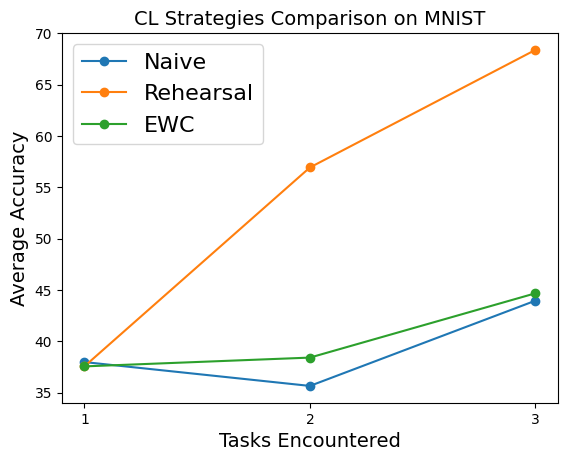

In [ ]:
plt.plot([1, 2, 3], naive_accs, '-o', label="Naive")
plt.plot([1, 2, 3], rehe_accs, '-o', label="Rehearsal")
plt.plot([1, 2, 3], ewc_accs, '-o', label="EWC")
plt.xlabel('Tasks Encountered', fontsize=14)
plt.ylabel('Average Accuracy', fontsize=14)
plt.title('CL Strategies Comparison on MNIST', fontsize=14);
plt.xticks([1, 2, 3])
plt.legend(prop={'size': 16});

### Actividad Práctica 4

*  Explique y haga una comparación entre los diferentes métodos mostrados en el gráfico anterior.
*  De ejemplos donde es mejor un método u otro. Explique sus razones.

# Material Extra

*   Sequoia ([Github](https://github.com/lebrice/Sequoia))
*   Avalanche ([Pagina](https://avalanche.continualai.org/))
*   Curso Continual AI ([YouTube](https://www.youtube.com/watch?v=z9DDg2CJjeE&list=PLm6QXeaB-XkBfM5RgQP6wCR7Jegdg51Px&ab_channel=ContinualAI))

